# A04 - ANÁLISIS DE RESIDUOS DE COLLEGE

## REGRESIÓN MÚLTIPLE CON INTERACCIÓN

In [1]:
# Librerías

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# La primera columna tiene el nombre de cada universidad, por eso la uso como índice

df = pd.read_csv("College.csv", index_col=0)

print(df)

                               Private   Apps  Accept  Enroll  Top10perc  \
Abilene Christian University       Yes   1660    1232     721         23   
Adelphi University                 Yes   2186    1924     512         16   
Adrian College                     Yes   1428    1097     336         22   
Agnes Scott College                Yes    417     349     137         60   
Alaska Pacific University          Yes    193     146      55         16   
...                                ...    ...     ...     ...        ...   
Worcester State College             No   2197    1515     543          4   
Xavier University                  Yes   1959    1805     695         24   
Xavier University of Louisiana     Yes   2097    1915     695         34   
Yale University                    Yes  10705    2453    1317         95   
York College of Pennsylvania       Yes   2989    1855     691         28   

                                Top25perc  F.Undergrad  P.Undergrad  Outstate  \
Abilen

In [3]:
# Private es categórica (Yes / No), así que la convierto en una variable de 1 y 0

df['Private'] = df['Private'].map({'Yes': 1, 'No': 0})

df['Private'].value_counts()

Private
1    565
0    212
Name: count, dtype: int64

Convertí la variable Private a valores numéricos para poder incluirla en la regresión. El valor 1 representa a las universidades privadas y el 0 a las públicas. En total hay 565 universidades privadas y 212 públicas.

In [4]:
# Interacción: porcentaje de alumnos del top 10% por gasto por estudiante

df['Top10perc_Expend'] = df['Top10perc'] * df['Expend']

df[['Top10perc', 'Expend', 'Top10perc_Expend']].head()

,Top10perc,Expend,Top10perc_Expend
Abilene Christian University,23,7041,161943
Adelphi University,16,10527,168432
Adrian College,22,8735,192170
Agnes Scott College,60,19016,1140960
Alaska Pacific University,16,10922,174752


Elegí la interacción entre Top10perc y Expend porque quiero analizar si el efecto del gasto por estudiante cambia según el porcentaje de alumnos que pertenecía al 10 % con mejores calificaciones. Al multiplicar ambas variables, el modelo ya no supone que el gasto produce el mismo cambio en todas las universidades.

In [5]:
# Regresión lineal múltiple con sklearn: Grad.Rate ~ todos los demás factores + interacción

Y = df['Grad.Rate']                     # Variable dependiente
X_v = df.drop(columns='Grad.Rate')      # Variables independientes (incluye la interacción)

modelo = LinearRegression()             # sklearn agrega el intercepto por su cuenta
modelo.fit(X_v, Y)

print('Intercepto:', modelo.intercept_)
print('R^2:', modelo.score(X_v, Y))

Intercepto: 41.13706690420851
R^2: 0.46343477264002786


In [6]:
# Regresión lineal múltiple con statsmodels

# statsmodels no toma en cuenta el intercepto, hay que agregar la columna de unos de tamaño n

ones = np.ones([df.shape[0], 1])
X = np.hstack([ones, X_v.values])
X = pd.DataFrame(X, columns=['intercepto'] + list(X_v.columns), index=df.index)

ols = sm.OLS(Y, X)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Grad.Rate   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     36.87
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           8.31e-91
Time:                        17:38:57   Log-Likelihood:                -3067.2
No. Observations:                 777   AIC:                             6172.
Df Residuals:                     758   BIC:                             6261.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercepto          37.9001      5.047      7.509      0.000      27.992      47.808
Private              3.7053      1.693      2.188      0.029       0.381       7.030
Apps                 0.0009      0.000      1.837      0.067   -5.92e-05       0.002
Accept            7.342e-05      0.001      0.081      0.935      -0.002       0.002
Enroll               0.0013      0.002      0.564      0.573      -0.003       0.006
Top10perc           -0.1069      0.093     -1.152      0.250      -0.289       0.075
Top25perc            0.1728      0.056      3.061      0.002       0.062       0.284
F.Undergrad         -0.0003      0.000     -0.867      0.386      -0.001       0.000
P.Undergrad         -0.0014      0.000     -3.694      0.000      -0.002      -0.001
Outstate             0.0011      0.000      4.695      0.000       0.001       0.002
Room.Board           0.0019      0.001      3.240      0.001       0.001       0.003
Books               -0.0015      0.003     -0.501      0.617      -0.007       0.004
Personal            -0.0018      0.001     -2.294      0.022      -0.003      -0.000
PhD                  0.0870      0.057      1.538      0.125      -0.024       0.198
Terminal            -0.0604      0.062     -0.971      0.332      -0.183       0.062
S.F.Ratio           -0.0202      0.162     -0.124      0.901      -0.339       0.299
perc.alumni          0.2773      0.049      5.663      0.000       0.181       0.373
Expend              -0.0011      0.000     -3.887      0.000      -0.002      -0.001
Top10perc_Expend  1.157e-05   4.23e-06      2.734      0.006    3.26e-06    1.99e-05
==============================================================================
Omnibus:                       35.608   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.536
Skew:                           0.133   Prob(JB):                     4.01e-22
Kurtosis:                       4.724   Cond. No.                     6.23e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.23e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [7]:
# Comparar los coeficientes de ambas librerías

coef = pd.DataFrame({
    'sklearn': np.append(modelo.intercept_, modelo.coef_),
    'statsmodels': results.params.values
}, index=X.columns)

coef

,sklearn,statsmodels
intercepto,41.137067,37.900136
Private,0.001362,3.705309
Apps,0.000767,0.000860
Accept,0.000184,0.000073
Enroll,0.001329,0.001309
Top10perc,-0.089413,-0.106862
Top25perc,0.170688,0.172783
F.Undergrad,-0.000466,-0.000348
P.Undergrad,-0.001482,-0.001436
Outstate,0.001264,0.001101


Los resultados de sklearn y statsmodels coinciden, por lo que ambos métodos ajustaron el mismo modelo. El valor de R² es 0.4668, lo cual indica que los factores incluidos explican aproximadamente el 46.7 % de las diferencias en la tasa de graduación. Además, el p-value general del modelo es menor a 0.05, por lo que en conjunto sí existe una relación estadísticamente significativa. De manera individual, los factores significativos son Private, Top25perc, P.Undergrad, Outstate, Room.Board, Personal, perc.alumni, Expend y la interacción Top10perc_Expend.

## INTERPRETACIÓN DE LA INTERACCIÓN

In [8]:
# El efecto de Expend depende de Top10perc: pendiente = b_Expend + b_interaccion * Top10perc

b_exp = results.params['Expend']
b_int = results.params['Top10perc_Expend']

top10 = [10, 20, 30, 50, 80]
efecto = pd.DataFrame({
    'Top10perc': top10,
    'Cambio en Grad.Rate por cada 1000 dólares de Expend': [(b_exp + b_int * t) * 1000 for t in top10]
})

efecto

,Top10perc,Cambio en Grad.Rate por cada 1000 dólares de Expend
0,10,-1.023131
1,20,-0.907476
2,30,-0.791821
3,50,-0.560510
4,80,-0.213544


El coeficiente de la interacción es positivo y su p-value es 0.006, por lo que la interacción sí es significativa. En la tabla puedo observar que, cuando Top10perc es 10, aumentar 1000 dólares en Expend se relaciona con una disminución aproximada de 1.02 puntos en Grad.Rate; cuando Top10perc es 80, la disminución es de sólo 0.21 puntos. Esto significa que el efecto negativo del gasto se hace menor conforme aumenta el porcentaje de alumnos del top 10 %.

## CÁLCULO DE LOS 6 PROBLEMAS DE LA REGRESIÓN LINEAL

In [9]:
# Calcular la y estimada y los residuos (con las predicciones de sklearn)

y_hat = modelo.predict(X_v)
E = Y - y_hat

res = pd.DataFrame({
    'y': Y,
    'y_hat': y_hat,
    'residuo': E
})

res.head()

,y,y_hat,residuo
Abilene Christian University,60,55.167451,4.832549
Adelphi University,56,63.043003,-7.043003
Adrian College,54,67.014006,-13.014006
Agnes Scott College,59,77.138688,-18.138688
Alaska Pacific University,15,49.784473,-34.784473


La fórmula a utilizar es $e = y - \hat{y}$. Un residuo positivo indica que el valor real quedó arriba de la predicción y uno negativo indica que el modelo predijo de más.

## 1. No linealidad

Predicciones mayores a 100: ['Duke University', 'Harvard University', 'Princeton University', 'Yale University']


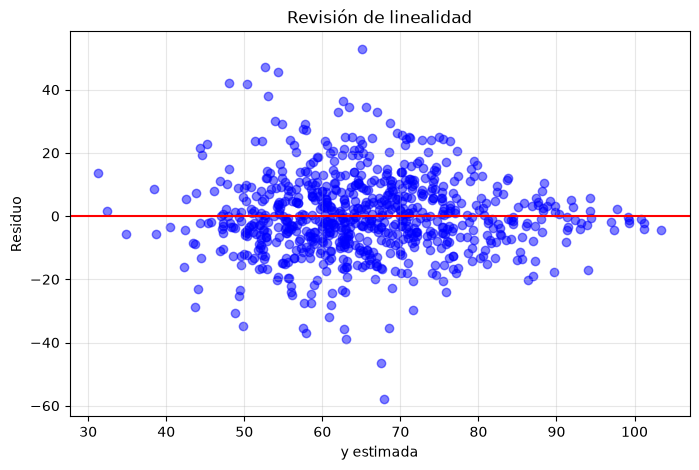

In [10]:
# Universidades con una predicción mayor a 100

print('Predicciones mayores a 100:', list(Y.index[y_hat > 100]))

# Residuos contra y estimada

plt.figure(figsize=(8, 5))
plt.scatter(y_hat, E, color='blue', alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel('y estimada')
plt.ylabel('Residuo')
plt.title('Revisión de linealidad')
plt.grid(alpha=0.3)
plt.show()

Los residuos se encuentran alrededor de cero y no forman una curva claramente definida, por lo que no observo una señal fuerte de no linealidad. Sin embargo, la dispersión es mayor en la parte central y el modelo genera cuatro predicciones mayores a 100, correspondientes a Duke, Harvard, Princeton y Yale. Como Grad.Rate es un porcentaje, esas predicciones no son posibles.

## 2. Correlación en los errores

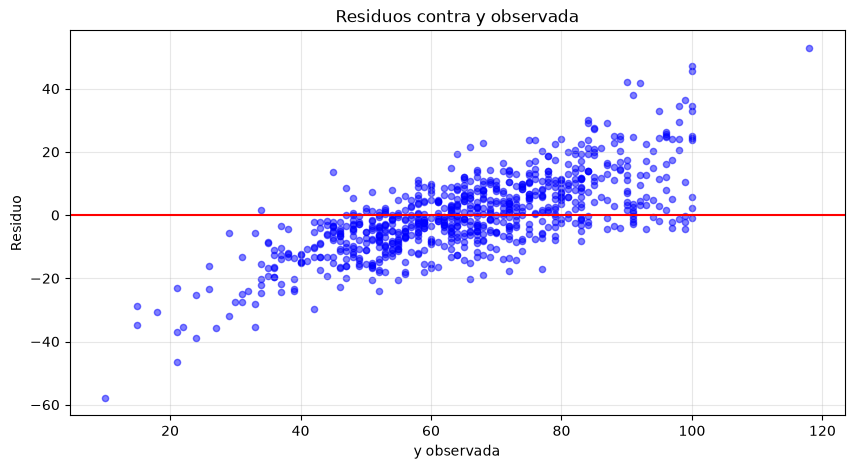

In [11]:
# Revisar los residuos contra y observada

plt.figure(figsize=(10, 5))
plt.scatter(Y, E, color='blue', alpha=0.5, s=20)
plt.axhline(0, color='red')
plt.xlabel('y observada')
plt.ylabel('Residuo')
plt.title('Residuos contra y observada')
plt.grid(alpha=0.3)
plt.show()

En la gráfica, observo una tendencia ascendente entre la y observada y los residuos. Para tasas de graduación bajas predominan los residuos negativos, mientras que para tasas altas aparecen más residuos positivos. Por ello, los errores no se ven distribuidos al azar y, siguiendo este criterio, sí existe una señal de correlación.

## 3. Varianza no constante en los errores

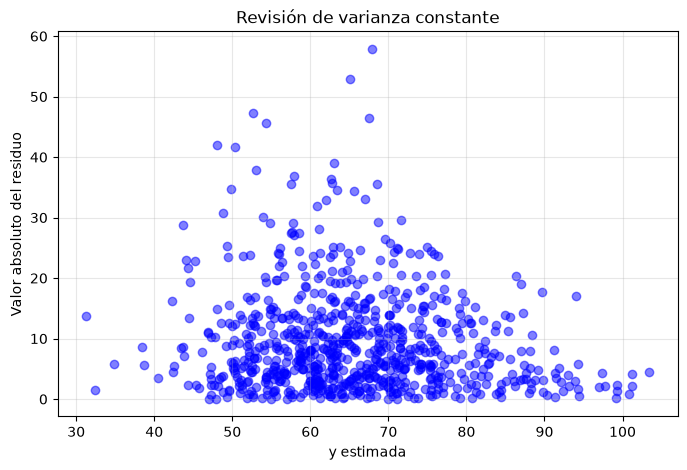

In [12]:
# Valor absoluto del residuo contra y estimada

plt.figure(figsize=(8, 5))
plt.scatter(y_hat, np.abs(E), color='blue', alpha=0.5)
plt.xlabel('y estimada')
plt.ylabel('Valor absoluto del residuo')
plt.title('Revisión de varianza constante')
plt.grid(alpha=0.3)
plt.show()

El tamaño de los residuos no se mantiene igual a lo largo de la y estimada. La mayor dispersión aparece aproximadamente entre predicciones de 50 y 75, mientras que en las predicciones más altas los residuos son más pequeños. Aunque no se forma un embudo perfecto, sí observo evidencia de que la varianza de los errores no es constante.

## 4. Valores atípicos

Observaciones atípicas: [ 96  99 318 320 378 395 586 732]


,y,y_hat,residuo / sigma
Cazenovia College,118,65.135407,4.152332
Centenary College,24,62.995956,-3.062999
Lindenwood College,100,54.369405,3.584127
Livingstone College,92,50.314424,3.274259
Missouri Southern State College,100,52.675289,3.717194
Mount Saint Clare College,21,67.490067,-3.651635
Texas Southern University,10,67.874681,-4.545858
Webber College,90,48.023823,3.297085


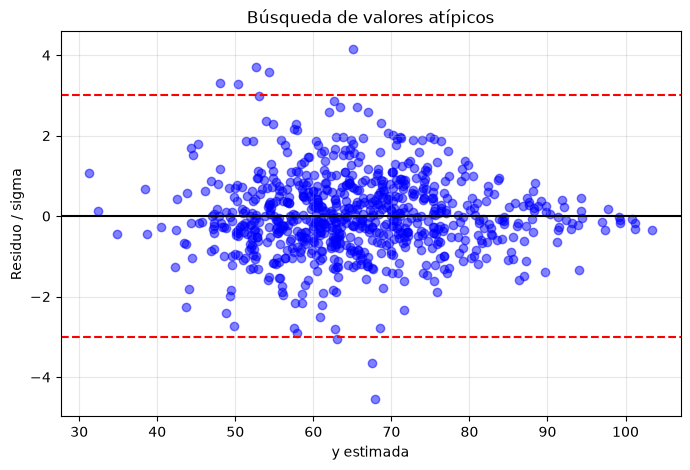

In [13]:
# Residuo dividido entre la desviación del error

n = len(Y)
p = X.shape[1]
sigma = np.sqrt(np.sum(E ** 2) / (n - p))
E_std = E / sigma

atipicos = np.where(np.abs(E_std) >= 3)[0]
print('Observaciones atípicas:', atipicos + 1)

display(pd.DataFrame({
    'y': Y.iloc[atipicos],
    'y_hat': y_hat[atipicos],
    'residuo / sigma': E_std.iloc[atipicos]
}))

plt.figure(figsize=(8, 5))
plt.scatter(y_hat, E_std, color='blue', alpha=0.5)
plt.axhline(0, color='black')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.xlabel('y estimada')
plt.ylabel('Residuo / sigma')
plt.title('Búsqueda de valores atípicos')
plt.grid(alpha=0.3)
plt.show()

Al aplicar el criterio de un residuo estandarizado mayor o igual a 3 en valor absoluto, encontré nueve observaciones atípicas. El caso positivo más extremo es Cazenovia College, con un valor de 4.15, y el negativo más extremo es Texas Southern University, con -4.55. Esto significa que sus valores observados quedaron bastante alejados de lo que predijo el modelo, aunque no demuestra por sí solo que los datos sean incorrectos.

## 5. Puntos palanca

Límite (p + 1) / n: 0.02445302445302445
Número de puntos palanca: 205


,Observación,h,residuo
Rutgers at New Brunswick,484,0.459572,-17.094114
University of Minnesota Twin Cities,641,0.364798,13.770336
Antioch University,21,0.300427,5.458646
Johns Hopkins University,285,0.220591,6.895036
Center for Creative Studies,101,0.210983,-3.589717


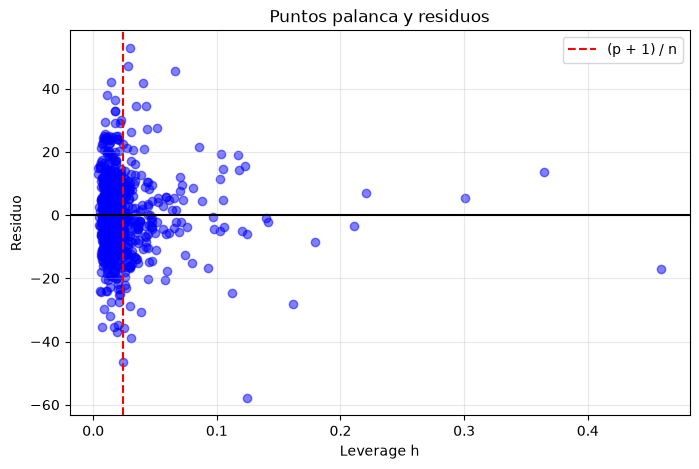

In [14]:
# Calcular el leverage de cada observación

inf = results.get_influence()
h = inf.hat_matrix_diag
p = X_v.shape[1]
h_lim = (p + 1) / n

palanca = np.where(h >= h_lim)[0]
print('Límite (p + 1) / n:', h_lim)
print('Número de puntos palanca:', len(palanca))

# Las 5 observaciones con mayor leverage
mayores = np.argsort(h)[::-1][:5]
display(pd.DataFrame({
    'Observación': mayores + 1,
    'h': h[mayores],
    'residuo': E.iloc[mayores]
}))

plt.figure(figsize=(8, 5))
plt.scatter(h, E, color='blue', alpha=0.5)
plt.axvline(h_lim, color='red', linestyle='--', label='(p + 1) / n')
plt.axhline(0, color='black')
plt.xlabel('Leverage h')
plt.ylabel('Residuo')
plt.title('Puntos palanca y residuos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El límite calculado con (p + 1) / n es 0.0245 y se identificaron 205 posibles puntos palanca, que son los puntos ubicados a la derecha de la línea roja. Rutgers at New Brunswick tiene el valor de palanca más alto, 0.4596, y además presenta un residuo de -17.09; University of Minnesota Twin Cities también tiene una palanca alta, 0.3648, y un residuo de 13.77.

## 6. Colinealidad

,Factor,VIF
0,Private,2.744768
1,Apps,15.819260
2,Accept,23.655183
3,Enroll,22.374021
4,Top10perc,12.901311
5,Top25perc,6.019414
6,F.Undergrad,18.287434
7,P.Undergrad,1.688959
8,Outstate,4.284695
9,Room.Board,2.005497


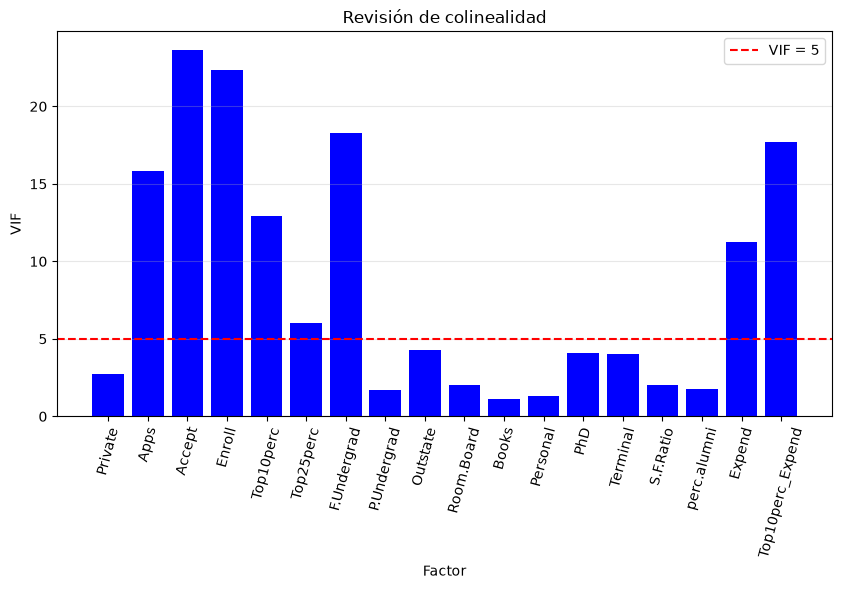

In [15]:
# Calcular el VIF de cada factor

vif = []
for i in range(1, X.shape[1]):
    vif.append(variance_inflation_factor(X.values, i))

vif = pd.DataFrame({
    'Factor': X.columns[1:],
    'VIF': vif
})

display(vif)

plt.figure(figsize=(10, 5))
plt.bar(vif['Factor'], vif['VIF'], color='blue')
plt.axhline(5, color='red', linestyle='--', label='VIF = 5')
plt.xlabel('Factor')
plt.ylabel('VIF')
plt.title('Revisión de colinealidad')
plt.xticks(rotation=75)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Los factores Apps, Accept, Enroll, Top10perc, Top25perc, F.Undergrad, Expend y Top10perc_Expend tienen un VIF mayor a 5. Por ello, sí existe un problema de colinealidad, especialmente entre las variables relacionadas con solicitudes, alumnos y la interacción. Esto puede hacer que algunos coeficientes cambien con facilidad y que sea más difícil interpretar el efecto individual de cada factor.

## CONCLUSIÓN

El modelo explica aproximadamente el 46.7 % de la variación en Grad.Rate y la interacción entre Top10perc y Expend resulta significativa. No encontré una señal fuerte de no linealidad, pero sí aparecen una relación entre la y observada y los residuos, cambios en la varianza, nueve valores atípicos, 205 posibles puntos palanca y varios factores con colinealidad. También, se obtuvieron cuatro predicciones mayores a 100 (cosa que no es posible) y, a partir de estos resultados, considero que el modelo permite encontrar relaciones útiles.